In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import xarray as xr

import sys
module_path = "../bin"
sys.path.insert(0,module_path)

import um_utils_plotting as umplt
import um_utils as um
import get_cpt
from geometry_fix import apply_geometry_collection_fix

apply_geometry_collection_fix()

np.set_printoptions(suppress=True)

um.WarningSuppress()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
#------------------------------------------------------------
# Bootstrapping function to return monthly mean and
# 95% C.I. from timeseries
#------------------------------------------------------------

def bootstrap_years_anom(years_old, years_new, n_boot=2000, rng=42):
    rng = np.random.default_rng(rng)
    n_years = years_old.shape[0]
    boot_mon_mean = np.empty((n_boot, 12))
    for i in range(n_boot):
        idx = rng.integers(0, n_years, n_years)
        boot_mon_mean[i] = years_new[idx].mean(dim="year") - years_old[idx].mean(dim="year")

    mon_mean = boot_mon_mean.mean(axis=0)
    ci_upper = np.percentile(boot_mon_mean, 97.5, axis=0)
    ci_lower = np.percentile(boot_mon_mean, 2.5, axis=0)

    return mon_mean, ci_upper, ci_lower

In [ ]:
#------------------------------------------------------------
# Bootstrap Precipitation Output
#------------------------------------------------------------

mhData = um.importUMData(f"../Data/Timeseries/MH/pr_197001-204912.nc") * (24*(60**2)*30)
piData = um.importUMData(f"../Data/Timeseries/PI/pr_187001-194912.nc") * (24*(60**2)*30)

GP_mask = umplt.umRegionMask("GP", mhData.longitude, mhData.latitude)

gp_mhData = mhData.where(GP_mask).mean(dim=["latitude", "longitude"]).coarsen(time=12).construct(time=["year", "month"])
gp_piData = piData.where(GP_mask).mean(dim=["latitude", "longitude"]).coarsen(time=12).construct(time=["year", "month"])
pr_mon_mean, pr_ci_upper, pr_ci_lower = bootstrap_years_anom(gp_piData, gp_mhData)

In [ ]:
#------------------------------------------------------------
# Load Humidity and Meridional Wind Timeseries (Large
# Arrays)
#------------------------------------------------------------

mh_q = um.importUMData(f"../Data/Timeseries/MH/q_plev_197001-204912.nc")
pi_q = um.importUMData(f"../Data/Timeseries/PI/q_plev_187001-194912.nc")

mh_v = um.importUMData(f"../Data/Timeseries/MH/v_wind_197001-204912.nc")
pi_v = um.importUMData(f"../Data/Timeseries/PI/v_wind_187001-194912.nc")

In [ ]:
#------------------------------------------------------------
# Calculate Integrated Meridional Moisture Flux (1000 - 
# 700 hPa) through southern GP border and bootstrap
#------------------------------------------------------------

g = 9.80665
R = 6.371e6

p = mh_v.air_pressure
vals = np.abs(np.diff(p.values, prepend=p.values[0])) * 100
dp = xr.DataArray(vals, coords={p.dims[0]: p.values}, dims=p.dims, name="dp")

# GPLLJ: Lat = 30°, Lon = -105 to -90°
# GP Lower Boundary: Lat = 33°, Lon = -100 to -92°
lat0 = 33.0
lon_min, lon_max = -100.0, -92.0

mh_Fv = (mh_q * mh_v * dp).sel(air_pressure=slice(1000, 700)).sum(dim="air_pressure") / g
pi_Fv = (pi_q * pi_v * dp).sel(air_pressure=slice(1000, 700)).sum(dim="air_pressure") / g

mh_Fv_line = mh_Fv.sel(latitude=lat0, method="nearest").sel(longitude=slice(lon_min + 360, lon_max + 360))
pi_Fv_line = pi_Fv.sel(latitude=lat0, method="nearest").sel(longitude=slice(lon_min + 360, lon_max + 360))

lons = mh_Fv_line.longitude.values
lats = mh_Fv_line.latitude.values

dlon_deg = np.abs(np.gradient(lons))
lat_rad = np.deg2rad(float(lats))
dx = R * np.cos(lat_rad) * np.deg2rad(dlon_deg)

dx_da = xr.DataArray(dx, coords={"longitude": lons}, dims=["longitude"])

mh_mFlux = (mh_Fv_line * dx_da).sum(dim="longitude").coarsen(time=12).construct(time=["year", "month"])
pi_mFlux = (pi_Fv_line * dx_da).sum(dim="longitude").coarsen(time=12).construct(time=["year", "month"])
mFlux_mon_mean, mFlux_ci_upper, mFlux_ci_lower = bootstrap_years_anom(pi_mFlux, mh_mFlux)

In [ ]:
#------------------------------------------------------------
# Calculate surface pressure and wind anomalies
# Calculate Moisture Flux Convergence with function
#------------------------------------------------------------

def calc_mFlux_conv(u, v, q, mult=86400):
    p_levs = u.p_levs.values
    dp = np.abs(np.diff(p_levs, prepend=p_levs[0])) * 100

    F_u = (q * u * dp.reshape((1,-1,1,1))).sum(dim="p_levs") / g
    F_v = (q * v * dp.reshape((1,-1,1,1))).sum(dim="p_levs") / g

    dF_dlon = F_u.differentiate("lon_p")
    dF_dlat = F_v.differentiate("lat_p")

    deg2rad = np.deg2rad(1.0)
    coslat = np.cos(np.deg2rad(F_u["lat_p"]))

    dFudx = dF_dlon / (R * coslat * deg2rad)
    dFvdy = dF_dlat / (R * deg2rad)

    divF = dFudx + dFvdy
    convF = -divF

    return convF * mult, F_u * mult, F_v * mult

MH_means = um.importUMData(f"../Data/Monthly_Means/MH_monthly_means_197001-204912.nc")
PI_means = um.importUMData(f"../Data/Monthly_Means/PI_monthly_means_187001-194912.nc")

p0_anom = (MH_means["surfpress"] - PI_means["surfpress"]) / 100
u_anom = MH_means["u_wind"].sel(p_levs=850) - PI_means["u_wind"].sel(p_levs=850)
v_anom = MH_means["v_wind"].sel(p_levs=850) - PI_means["v_wind"].sel(p_levs=850)

mh_convF, mh_Fu, mh_Fv = calc_mFlux_conv(MH_means["u_wind"], MH_means["v_wind"], MH_means["q_plev"], mult=86400*30)
pi_convF, pi_Fu, pi_Fv = calc_mFlux_conv(PI_means["u_wind"], PI_means["v_wind"], PI_means["q_plev"], mult=86400*30)
convF_anom = mh_convF - pi_convF

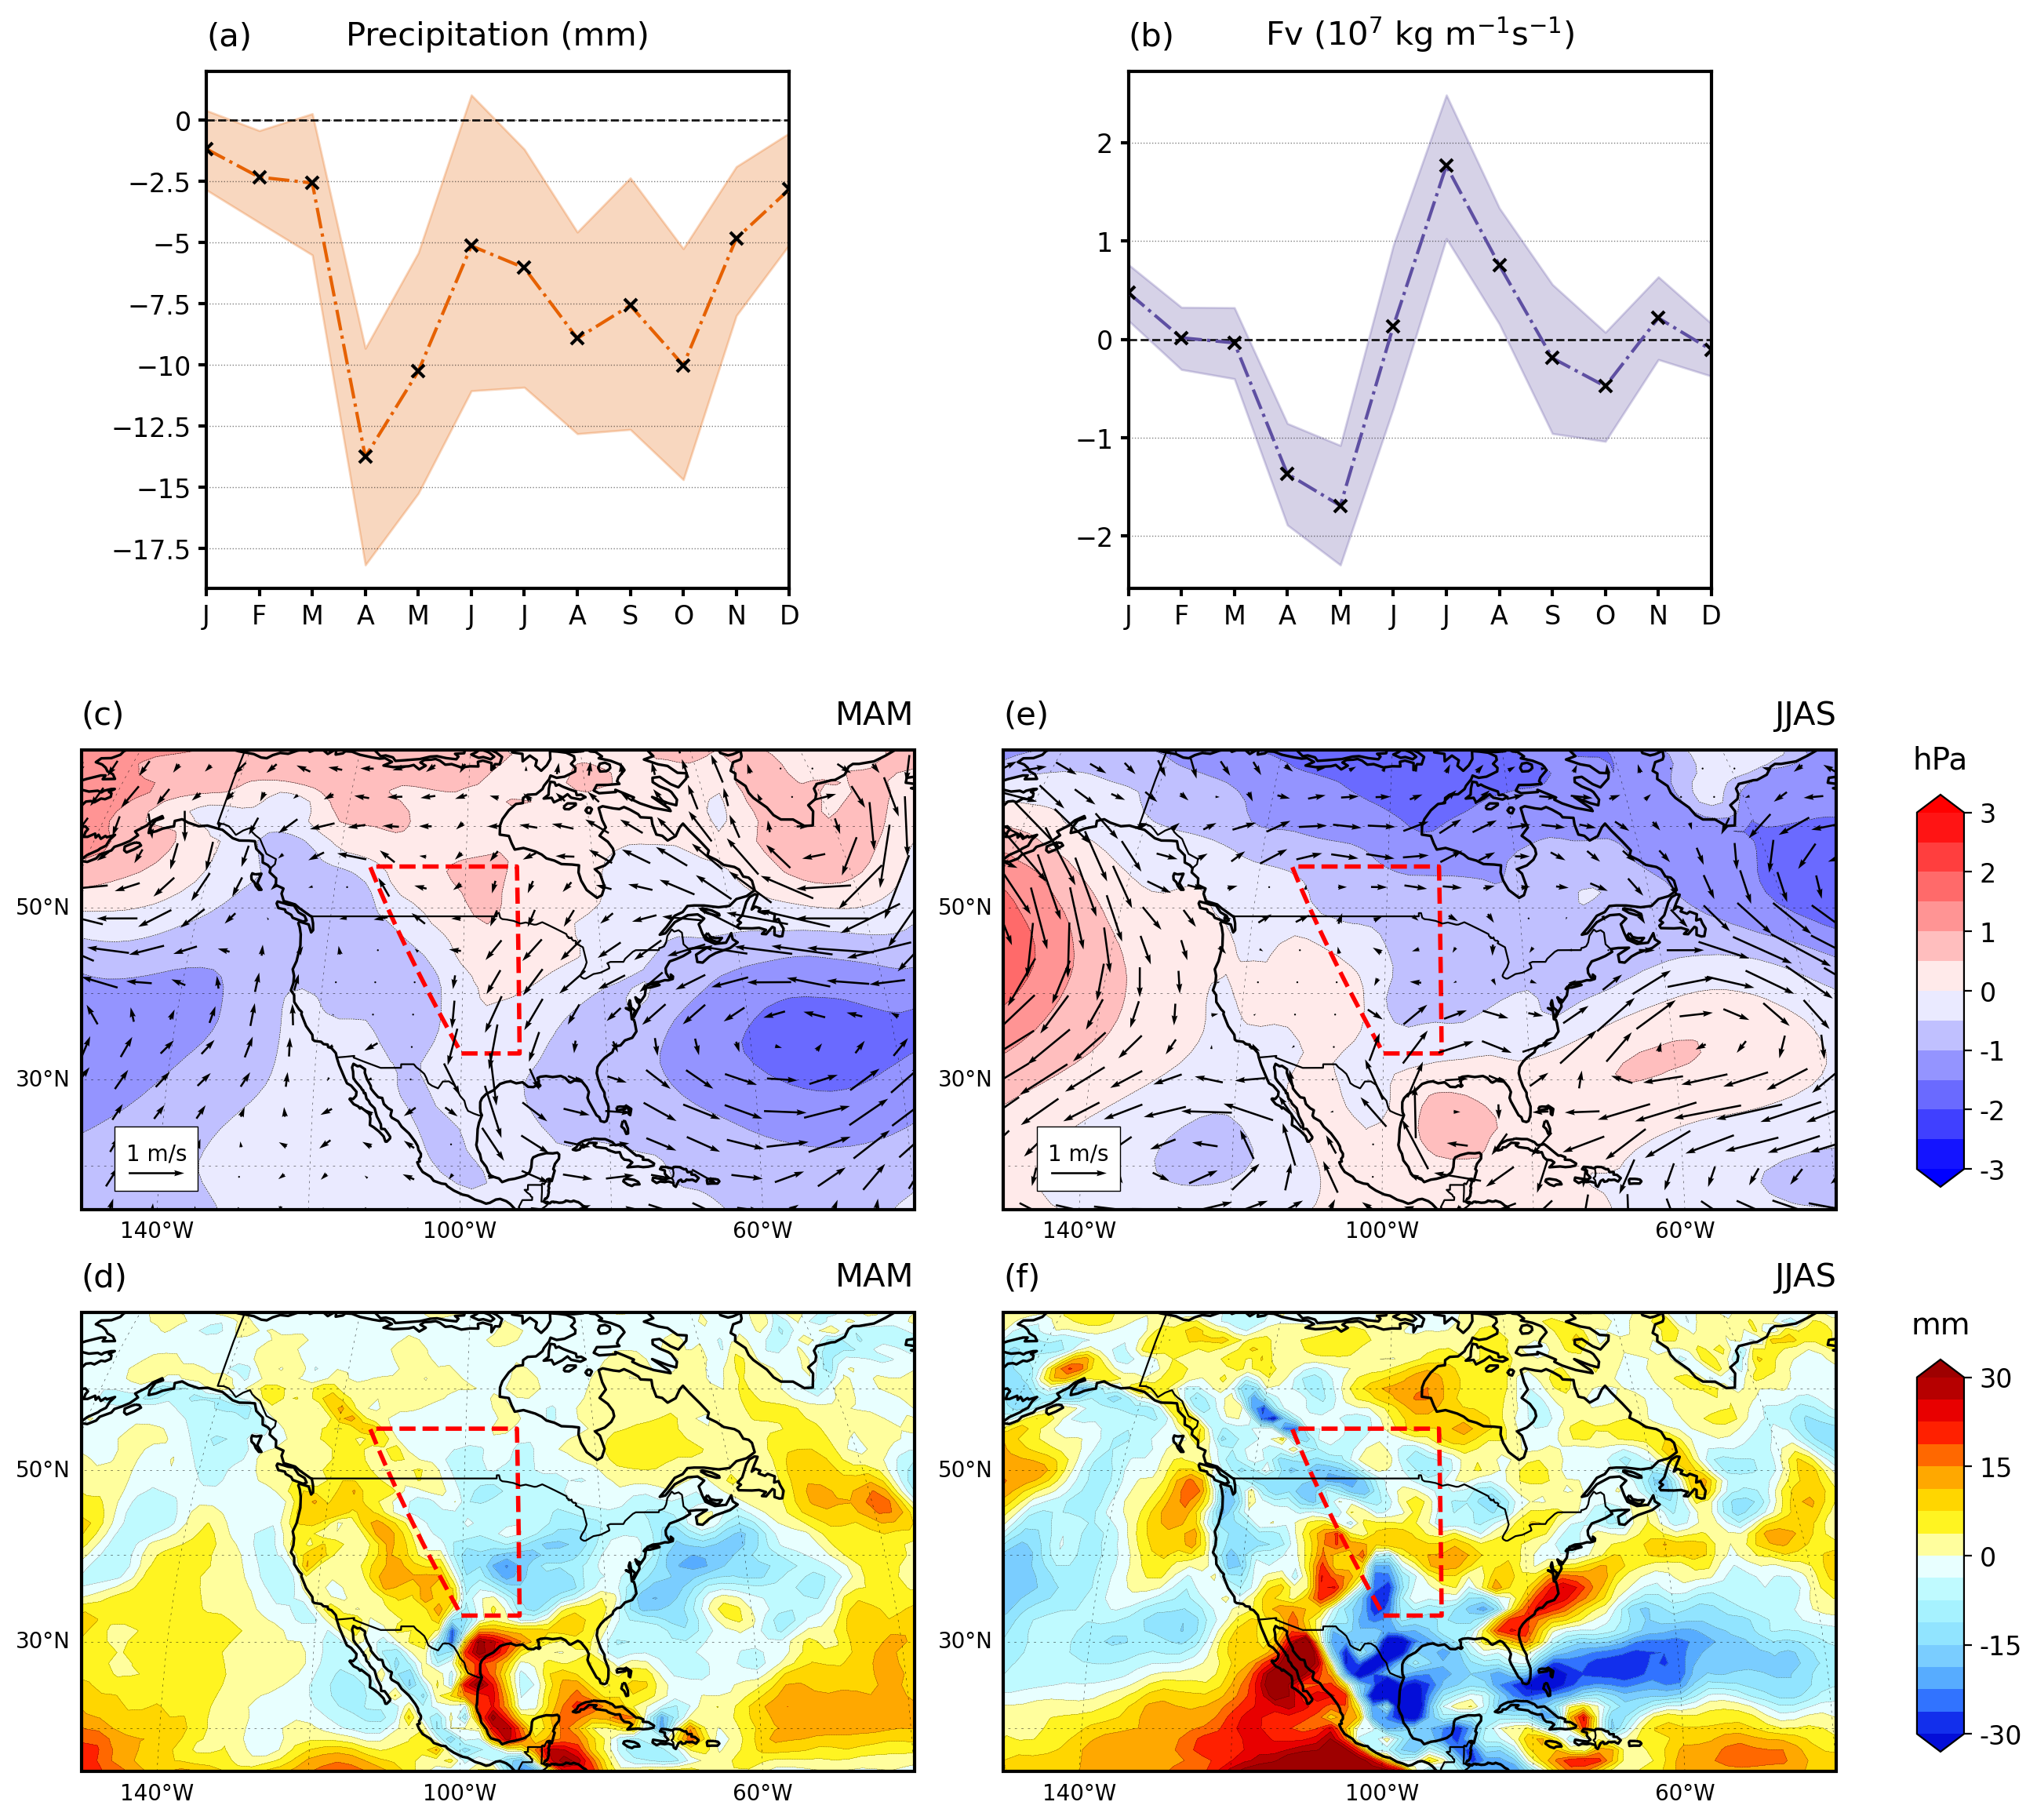

In [ ]:
#------------------------------------------------------------
# Plot Figure
#------------------------------------------------------------

fig = plt.figure(figsize=(12, 10), dpi=200)
gs = gridspec.GridSpec(3, 2, height_ratios=[0.7, 1, 1])
lims, proj = [-150, -40, 15, 70], ccrs.Robinson(central_longitude=-95)
GP_region = umplt.umRegion("GP")

#---------------------------------------
# Properties for Line Plots
#---------------------------------------

lineplotData = [(pr_mon_mean, pr_ci_upper, pr_ci_lower), (mFlux_mon_mean * 1e-07, mFlux_ci_upper * 1e-07, mFlux_ci_lower * 1e-07)]
plot_time = np.arange(12)
colors = ["#E66101", "#5E4FA2"]
titles = ["Precipitation (mm)", r"Fv ($\mathregular{10^{7}}$ kg $\mathregular{m^{-1} s^{-1}}$)"]
xticklabs = ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]
plot_labels = ["a", "b"]

#---------------------------------------
# Plotting line plots
#---------------------------------------

for i, (mon_mean, ci_upper, ci_lower) in enumerate(lineplotData):
    ax = plt.subplot(gs[0, i])

    ax.plot(plot_time, mon_mean, lw=1.5, ls="dashdot", color=colors[i], marker="x", mew=1.5, mec="black", zorder=5)
    ax.fill_between(plot_time, ci_upper, ci_lower, alpha=0.25, color=colors[i], lw=1)

    ax.grid(True, which="major", axis="y", ls="dotted", color="black", alpha=0.5, lw=0.5, zorder=3)

    yticks = ax.get_yticks()
    gridlines = ax.yaxis.get_gridlines()
    for ytick, gl in zip(yticks, gridlines):
        if np.isclose(ytick, 0.0, atol=1e-8):
            gl.set_visible(False)
            break

    ax.axhline(0, ls="dashed", color="black", alpha=0.9, lw=1, zorder=4)
    if i == 0:
        ax.axhline(-10, ls="dotted", color="black", alpha=0.5, lw=0.5, zorder=3)

    ax.set_xticks(np.arange(0, 12), labels=xticklabs, fontsize=12)
    ax.set_xlim(min(plot_time), max(plot_time))
    ax.tick_params("both", width=1.5)
    ax.tick_params(axis="y", labelsize=12)
    if i == 0:
        ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:g}'))

    ax.set_title(titles[i], fontsize=15, pad=12)
    ax.set_title(f"({plot_labels[i]})", loc="left", fontsize=15, pad=12)

    ax.spines[["top", "bottom", "right", "left"]].set_linewidth(1.5)

#---------------------------------------
# Properties for Anomaly Maps
#---------------------------------------

LON, LAT = np.meshgrid(MH_means.longitude, MH_means.latitude)

variables = ["p0", "MFC"]
periods = [("MAM", [2, 3, 4]), ("JJAS", [5, 6, 7, 8])]
map_labels = np.array([["c", "e"], ["d", "f"]])

step = 3
U = u_anom[:, ::step, ::step]
V = v_anom[:, ::step, ::step]
X, Y = np.meshgrid(U.lon_p.values, U.lat_p.values)

#------------------------------------------------------------
# Plotting Maps for Pressure and MFC
#------------------------------------------------------------

for i, var in enumerate(variables):
    if var == "p0":
        modelAnom = p0_anom
        plt_wnd = True; clw=0.2
        cmap = cm.bwr; v = 3; levs = np.linspace(-v, v, 13); cbar_lab = r"hPa"
        cbar_axes_loc = (1.025, 0.4, 0.025, 0.25); cbar_ticks = levs[::2]; strfmt = "{:g}" 
        LON, LAT = np.meshgrid(modelAnom.longitude, modelAnom.latitude)

    elif var == "MFC":
        modelAnom = convF_anom
        plt_wnd = False; clw=0.1
        cmap = get_cpt.get_cmap("GMT_panoply_diff.cpt"); v = 30; levs = np.linspace(-v, v, 17); cbar_lab = r"mm"
        cbar_axes_loc = (1.025, 0.04, 0.025, 0.25); cbar_ticks = levs[::4]; strfmt = "{:g}"
        LON, LAT = np.meshgrid(modelAnom.lon_p, modelAnom.lat_p)

    for j, (period, months) in enumerate(periods):
        ax = plt.subplot(gs[i + 1, j], projection=proj)
        umplt.plotBaseMap(ax, lims, coastlw=1.2, bordercol="black", borderlw=0.8, spinelw=1.5)
        umplt.plotGrid(ax, xlabeledlines=[-60, -100, -140], ylabeledlines=[30, 50],
                       xlines=[-40, -80, -120, -160], ylines=[20, 40, 60], labelsize=10, lw=0.2)
        
        anom = modelAnom.isel(time=months).mean(dim="time")

        filled_contour = ax.contourf(LON, LAT, anom, extend="both", cmap=cmap, levels=levs, transform=ccrs.PlateCarree(), transform_first=True, zorder=0)
        contour = ax.contour(LON, LAT, anom, extend="both", colors="black", levels=levs, linestyles="dashed", linewidths=clw, transform=ccrs.PlateCarree(), transform_first=True, zorder=0)

        if plt_wnd:
            U_mean = U.isel(time=months).mean(dim="time").values
            V_mean = V.isel(time=months).mean(dim="time").values
            wind = ax.quiver(X, Y, U_mean, V_mean, pivot="mid", color="black", scale=15, scale_units="width", transform=ccrs.PlateCarree(), zorder=10)
                
            # Quiver key for each subplot
            rectangle = patches.Rectangle((0.04, 0.04), 0.1, 0.14, edgecolor=(0, 0, 0, 1), facecolor=(1, 1, 1, 1), linewidth=0.5, transform=ax.transAxes, zorder=10)
            ax.add_patch(rectangle)
            ax.quiverkey(wind, 0.09, 0.08, 1, '1 m/s', coordinates='axes', fontproperties={'size': 10}, color='k', labelsep=0.05, zorder=10)    

        line_kws = {"color": "red", "linestyle": "dashed", "linewidth": 2, "zorder": 0}
        GP_region.plot(ax=ax, line_kws=line_kws, add_coastlines=False, add_label=False)

        ax.set_title(period, loc="right", fontsize=15, pad=12)
        ax.set_title(f"({map_labels[i,j]})", loc="left", fontsize=15, pad=12)

    cbaxes = fig.add_axes(cbar_axes_loc)
    cbar = plt.colorbar(filled_contour, extend='both', orientation='vertical', ticks=cbar_ticks, cax=cbaxes)
    cbar.set_ticks(cbar_ticks, labels=[strfmt.format(x) for x in cbar.get_ticks()], fontsize=12) 
    cbar.ax.set_title(cbar_lab, fontsize=14, pad=20)   

plt.tight_layout()

axes = fig.get_axes()
axes_to_adjust = [ax for ax in axes if ax.get_title() in titles]
for ax in axes_to_adjust:
    umplt.ax_adjust(ax, shrinkx=0.7, shrinky=1.6, shifty=0.1)

plt.show()